In [1]:
# ASSIGNMENT 2: Multi-Model AI Comparative Analysis
# FINANCIAL FRAUD DETECTION
# ========================================
# Student Name: [Marah Akram Abou Abdo]
# Date: July 2026
# ========================================

# Project Description
# ========================================
# Topic: Financial Fraud Detection
# Dataset: AIML Dataset.csv
# Target Variable: isFraud (0 = Legitimate, 1 = Fraud)
# Models Used: 
#   1. Logistic Regression
#   2. Random Forest
#   3. XGBoost
# ========================================

In [2]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
# Step 2: Load And Explore Dataset

# Read csv file
df = pd.read_csv("AIML Dataset.csv")

# Display first 5 rows
print("First 5 rows of dataset:")
print("="*50)
df.head()

# Display dataset info
print("\nDataset Information:")
print("="*50)
df.info()

# Display column names
print("\nColumn Names:")
print("="*50)
print(df.columns.tolist())

First 5 rows of dataset:

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [4]:
# Step 3: Exploratory Data Analysis (EDA)

# Check fraud distribution
print("\nFraud Distribution:")
print("="*50)
print(df["isFraud"].value_counts())
print(f"\nFraud Percentage: {round((df['isFraud'].sum() / df.shape[0]) * 100, 2)}%")

# Check flagged fraud
print("\nFlagged Fraud Distribution:")
print("="*50)
print(df["isFlaggedFraud"].value_counts())

# Check for missing values
print("\nMissing Values:")
print("="*50)
print(f"Total missing values: {df.isnull().sum().sum()}")

# Dataset shape
print("\nDataset Shape:")
print("="*50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Transaction types distribution
print("\nTransaction Types:")
print("="*50)
print(df["type"].value_counts())


Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage: 0.13%

Flagged Fraud Distribution:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Missing Values:
Total missing values: 0

Dataset Shape:
Rows: 6362620, Columns: 11

Transaction Types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


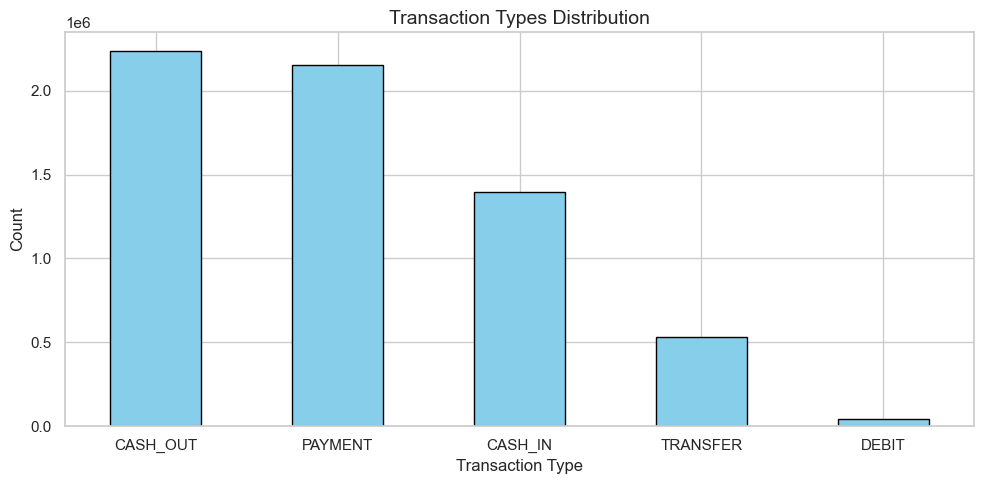

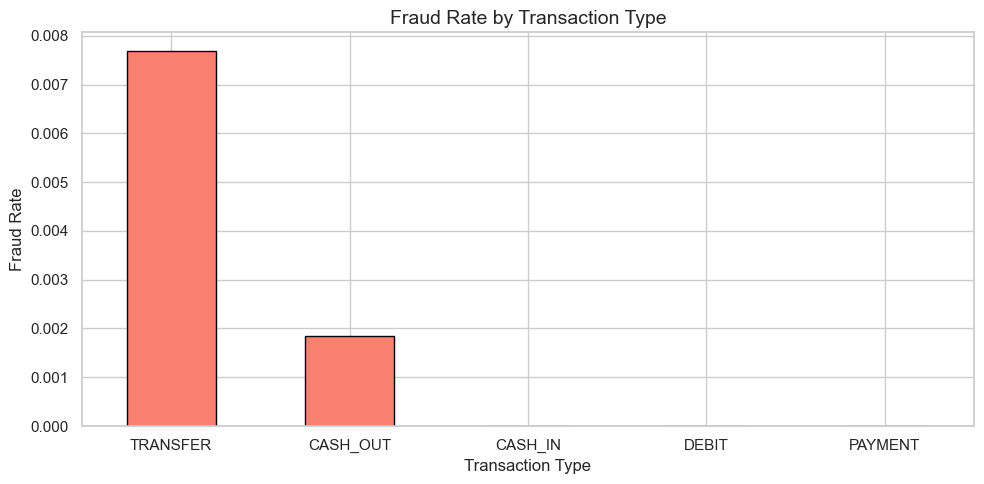


Fraud Rate by Type:
type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [5]:
# Step 4: Visualization - EDA

# Plot 1: Transaction Types
plt.figure(figsize=(10, 5))
df["type"].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Transaction Types Distribution", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Fraud Rate by Transaction Type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
fraud_by_type.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Fraud Rate by Transaction Type", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nFraud Rate by Type:")
print("="*50)
print(fraud_by_type)


Transaction Amount Statistics:
count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64


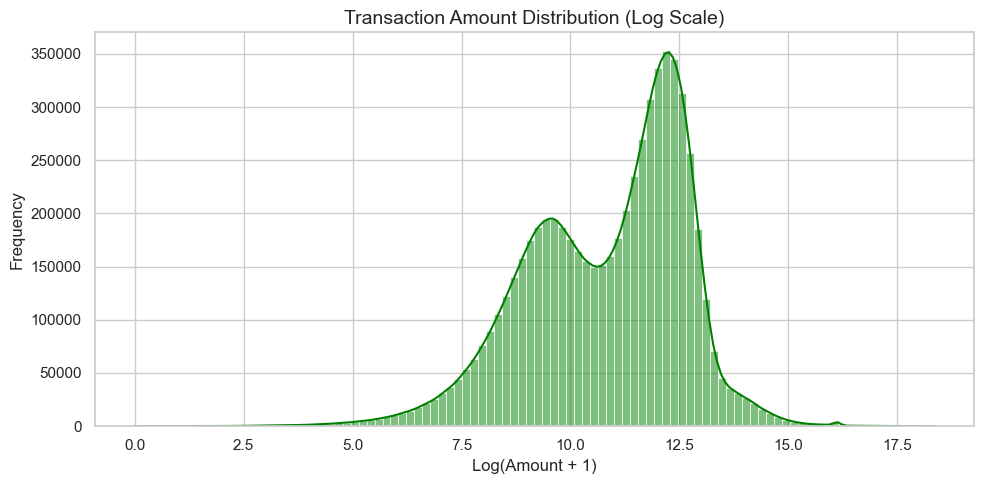

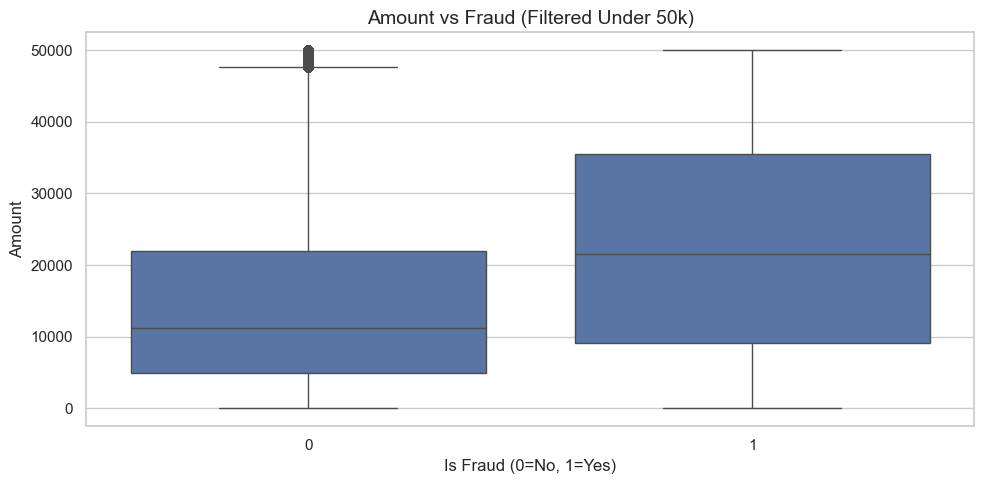

In [6]:
# Step 5: Transaction Amount Analysis

# Summary statistics for amount
print("\nTransaction Amount Statistics:")
print("="*50)
print(df["amount"].describe().astype(int))

# Plot 3: Amount Distribution (Log Scale)
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (Log Scale)", fontsize=14)
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot 4: Boxplot - Amount vs Fraud
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["amount"] < 50000], x="isFraud", y="amount")
plt.title("Amount vs Fraud (Filtered Under 50k)", fontsize=14)
plt.xlabel("Is Fraud (0=No, 1=Yes)")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


Balance Difference Analysis:
Negative balance diff (Origin): 1399253
Negative balance diff (Destination): 1238864

First 2 rows with new features:


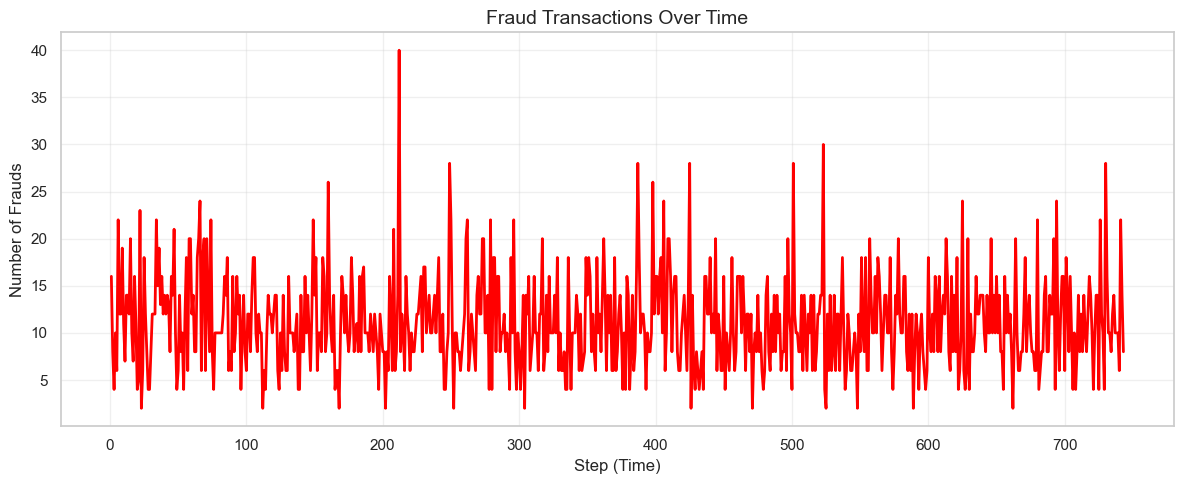

In [7]:
# Step 6: Feature Engineering

# Create balance difference features
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

# Check negative balances
print("\nBalance Difference Analysis:")
print("="*50)
print(f"Negative balance diff (Origin): {(df['balanceDiffOrig'] < 0).sum()}")
print(f"Negative balance diff (Destination): {(df['balanceDiffDest'] < 0).sum()}")

# Display first 2 rows with new features
print("\nFirst 2 rows with new features:")
print("="*50)
df.head(2)

# Plot 5: Fraud over time
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(frauds_per_step.index, frauds_per_step.values, color="red", linewidth=2)
plt.title("Fraud Transactions Over Time", fontsize=14)
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drop step column (no longer needed)
df.drop(columns=["step"], inplace=True)


Top 10 Senders by Transaction Count:
nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

Top 10 Receivers by Transaction Count:
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

Top 10 Fraudulent Senders:
nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64


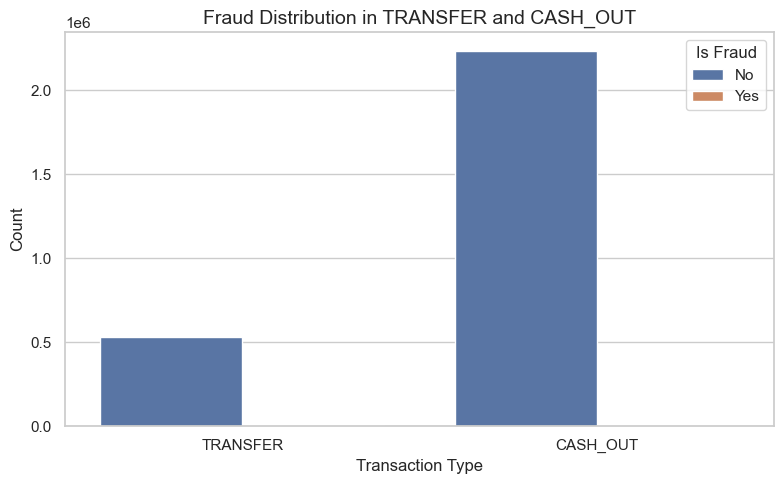


Transactions with zero balance after transfer: 1188074


In [8]:
# Step 7: Sender And Receiver Analysis

# Top 10 senders
top_senders = df["nameOrig"].value_counts().head(10)
print("\nTop 10 Senders by Transaction Count:")
print("="*50)
print(top_senders)

# Top 10 receivers
top_receivers = df["nameDest"].value_counts().head(10)
print("\nTop 10 Receivers by Transaction Count:")
print("="*50)
print(top_receivers)

# Top 10 fraud users
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
print("\nTop 10 Fraudulent Senders:")
print("="*50)
print(fraud_users)

# Filter fraud types (TRANSFER and CASH_OUT only)
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

# Plot 6: Fraud Distribution by Transaction Type
plt.figure(figsize=(8, 5))
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in TRANSFER and CASH_OUT", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title="Is Fraud", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# Check zero balance after transfer
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]
print(f"\nTransactions with zero balance after transfer: {len(zero_after_transfer)}")


Correlation Matrix:
                  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
amount          1.000000      -0.002762       -0.007861        0.294137   
oldbalanceOrg  -0.002762       1.000000        0.998803        0.066243   
newbalanceOrig -0.007861       0.998803        1.000000        0.067812   
oldbalanceDest  0.294137       0.066243        0.067812        1.000000   
newbalanceDest  0.459304       0.042029        0.041837        0.976569   
isFraud         0.076688       0.010154       -0.008148       -0.005885   

                newbalanceDest   isFraud  
amount                0.459304  0.076688  
oldbalanceOrg         0.042029  0.010154  
newbalanceOrig        0.041837 -0.008148  
oldbalanceDest        0.976569 -0.005885  
newbalanceDest        1.000000  0.000535  
isFraud               0.000535  1.000000  


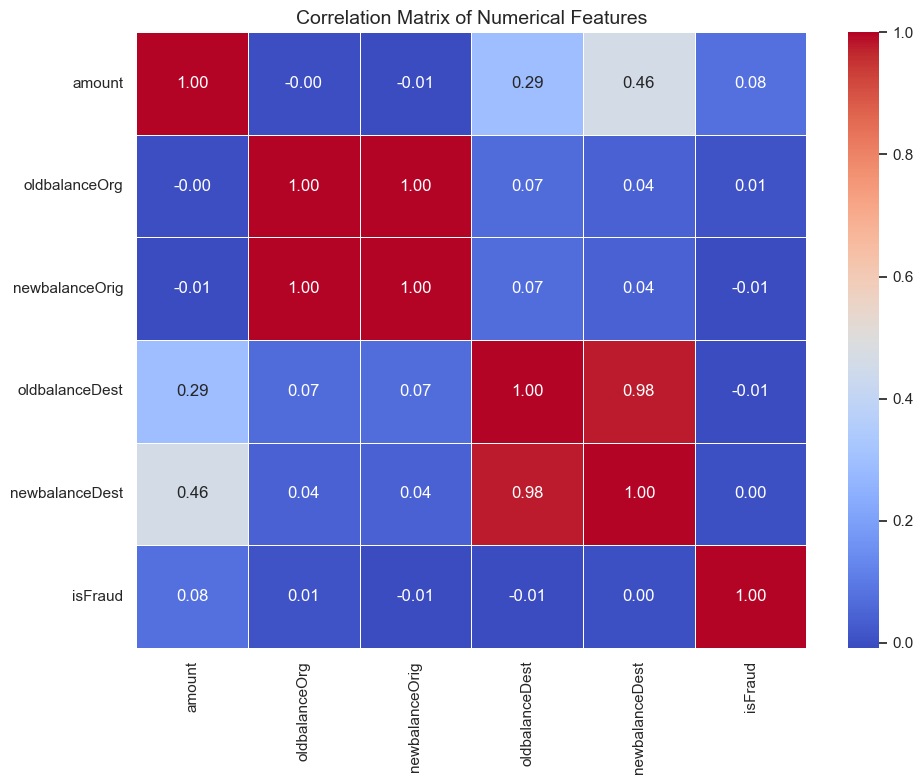


Correlation with isFraud (Target Variable):
isFraud           1.000000
amount            0.076688
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [9]:
# Step 8: Correlation Matrix

# Select numerical columns for correlation
corr_columns = ["amount", "oldbalanceOrg", "newbalanceOrig", 
                "oldbalanceDest", "newbalanceDest", "isFraud"]

# Calculate correlation
corr = df[corr_columns].corr()

print("\nCorrelation Matrix:")
print("="*50)
print(corr)

# Plot 7: Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

# Highlight important correlations with isFraud
print("\nCorrelation with isFraud (Target Variable):")
print("="*50)
print(corr["isFraud"].sort_values(ascending=False))

In [10]:
# Step 9: Data Preprocessing For Modeling
# Drop unnecessary columns
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)
print("\nColumns after dropping unnecessary features:")
print("="*50)
print(df_model.columns.tolist())

# Define features
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

# Define target and features
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

# Train-test split (70-30)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"\nData Split:")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Fraud in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in testing: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Columns after dropping unnecessary features:
['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'balanceDiffOrig', 'balanceDiffDest']

Data Split:
Training set: 4453834 samples
Testing set: 1908786 samples
Fraud in training: 5749 (0.13%)
Fraud in testing: 2464 (0.13%)


In [12]:
# Step 10: Create Preprocessor Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical)
    ],
    remainder="drop"
)

# Test the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)

print("\nPreprocessor Test:")
print("="*50)
print(f"Original features: {X_train.shape[1]}")
print(f"Processed features: {X_train_processed.shape[1]}")


Preprocessor Test:
Original features: 8
Processed features: 9


In [13]:
# Step 11: Model 1 - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create pipeline
pipeline_lr = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# Train model
print("\nTraining Logistic Regression...")
pipeline_lr.fit(X_train, y_train)

# Predict
y_pred_lr = pipeline_lr.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Accuracy
accuracy_lr = pipeline_lr.score(X_test, y_test) * 100
print(f"\nAccuracy: {accuracy_lr:.2f}%")


Training Logistic Regression...

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786


Confusion Matrix:
[[1804823  101499]
 [    151    2313]]

Accuracy: 94.67%


In [14]:
# Step 12: Model 2 - Random Forest

from sklearn.ensemble import RandomForestClassifier

# Create pipeline
pipeline_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train model
print("\nTraining Random Forest...")
pipeline_rf.fit(X_train, y_train)

# Predict
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Accuracy
accuracy_rf = pipeline_rf.score(X_test, y_test) * 100
print(f"\nAccuracy: {accuracy_rf:.2f}%")


Training Random Forest...

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.96      0.78      0.86      2464

    accuracy                           1.00   1908786
   macro avg       0.98      0.89      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786


Confusion Matrix:
[[1906252      70]
 [    548    1916]]

Accuracy: 99.97%


In [15]:
# Step 13: Model 3 - XGBoost

from xgboost import XGBClassifier

# Create pipeline
pipeline_xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        scale_pos_weight=10,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Train model
print("\nTraining XGBoost...")
pipeline_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = pipeline_xgb.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("XGBOOST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# Accuracy
accuracy_xgb = pipeline_xgb.score(X_test, y_test) * 100
print(f"\nAccuracy: {accuracy_xgb:.2f}%")


Training XGBoost...

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.74      0.89      0.81      2464

    accuracy                           1.00   1908786
   macro avg       0.87      0.94      0.90   1908786
weighted avg       1.00      1.00      1.00   1908786


Confusion Matrix:
[[1905534     788]
 [    272    2192]]

Accuracy: 99.94%


In [16]:
# Step 14: Save All Models
import joblib

# Save models
joblib.dump(pipeline_lr, "Logistic_Regression.pkl")
joblib.dump(pipeline_rf, "Random_Forest.pkl")
joblib.dump(pipeline_xgb, "XGBoost.pkl")

print("\nAll models saved successfully!")
print("="*50)
print("Files created:")
print("  - Logistic_Regression.pkl")
print("  - Random_Forest.pkl")
print("  - XGBoost.pkl")


All models saved successfully!
Files created:
  - Logistic_Regression.pkl
  - Random_Forest.pkl
  - XGBoost.pkl



MODEL COMPARISON TABLE
              Model Accuracy Precision Recall     F1 ROC-AUC
Logistic Regression   94.67%     2.23% 93.87%  4.35%  98.91%
      Random Forest   99.97%    96.48% 77.76% 86.11%  99.48%
            XGBoost   99.94%    73.56% 88.96% 80.53%  99.97%


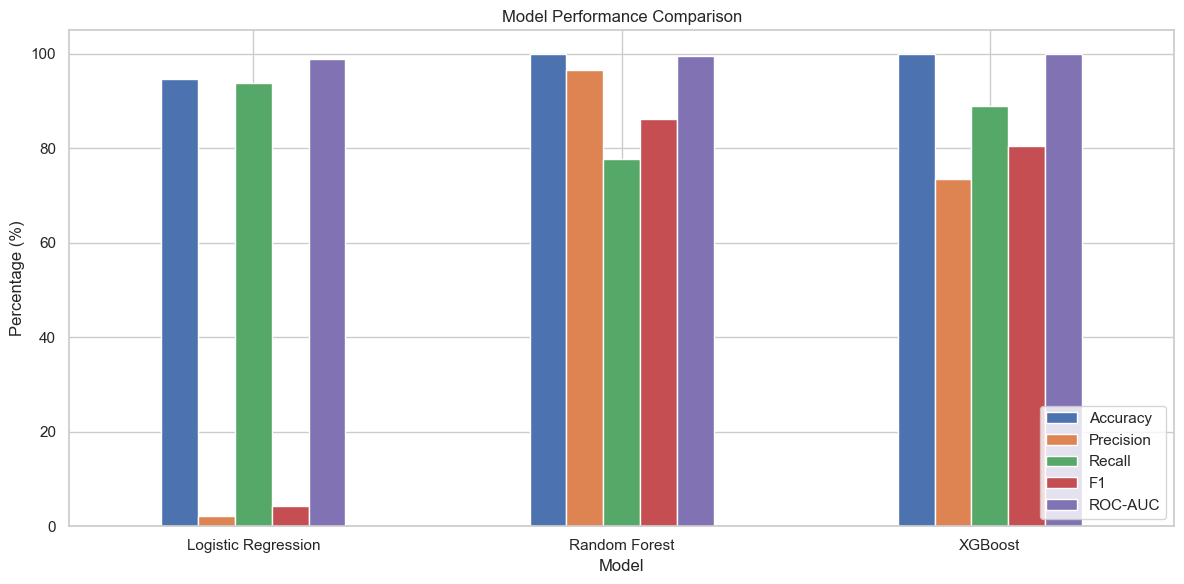

In [17]:
# Step 15: Model Comparison Table

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# List of models
models = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

# Store results
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
    "Model": name,
    "Accuracy": f"{accuracy*100:.2f}%",
    "Precision": f"{precision*100:.2f}%",
    "Recall": f"{recall*100:.2f}%",
    "F1": f"{f1*100:.2f}%",
    "ROC-AUC": f"{roc_auc*100:.2f}%"
    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Display table
print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string(index=False))

# Convert percentage columns to numeric values for plotting
comparison_df["Accuracy"] = comparison_df["Accuracy"].str.replace("%", "").astype(float)
comparison_df["Precision"] = comparison_df["Precision"].str.replace("%", "").astype(float)
comparison_df["Recall"] = comparison_df["Recall"].str.replace("%", "").astype(float)
comparison_df["F1"] = comparison_df["F1"].str.replace("%", "").astype(float)
comparison_df["ROC-AUC"] = comparison_df["ROC-AUC"].str.replace("%", "").astype(float)

# Plot with Model as index
comparison_df.set_index("Model").plot(
    kind="bar", 
    figsize=(12, 6), 
    title="Model Performance Comparison"
)
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

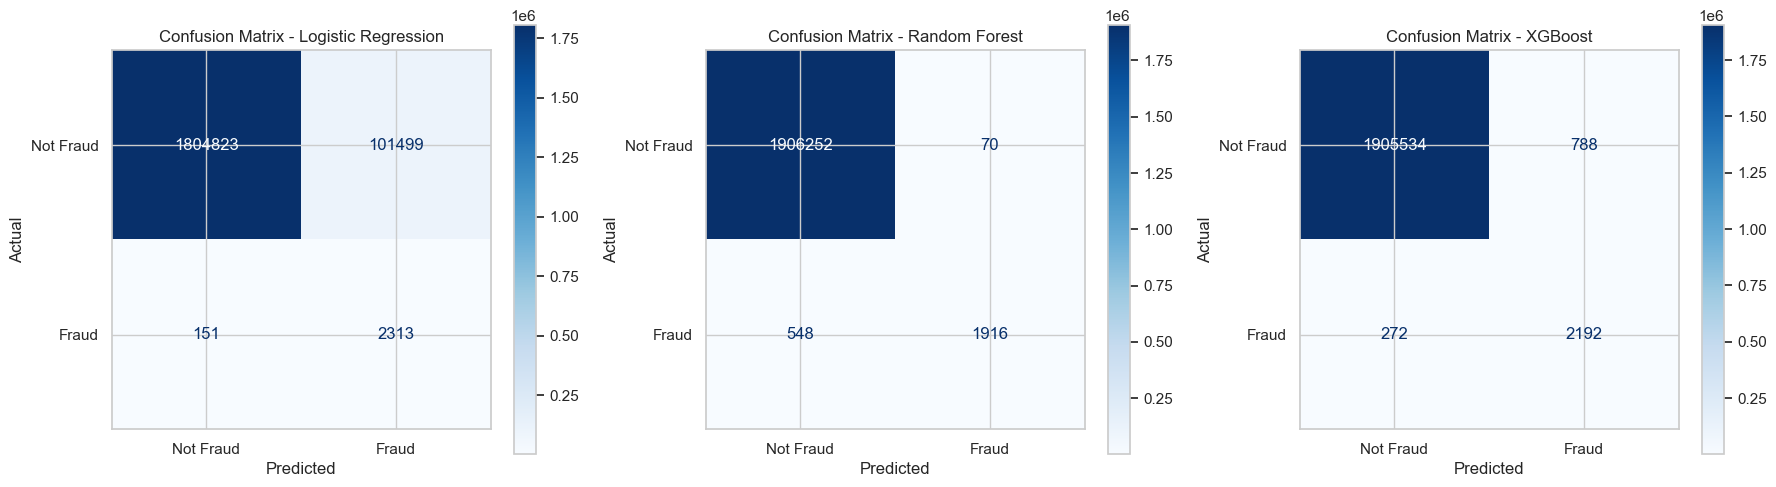

In [18]:
# Step 16: Confusion Matrices For All Models

from sklearn.metrics import ConfusionMatrixDisplay

# List of models
models_viz = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_viz.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

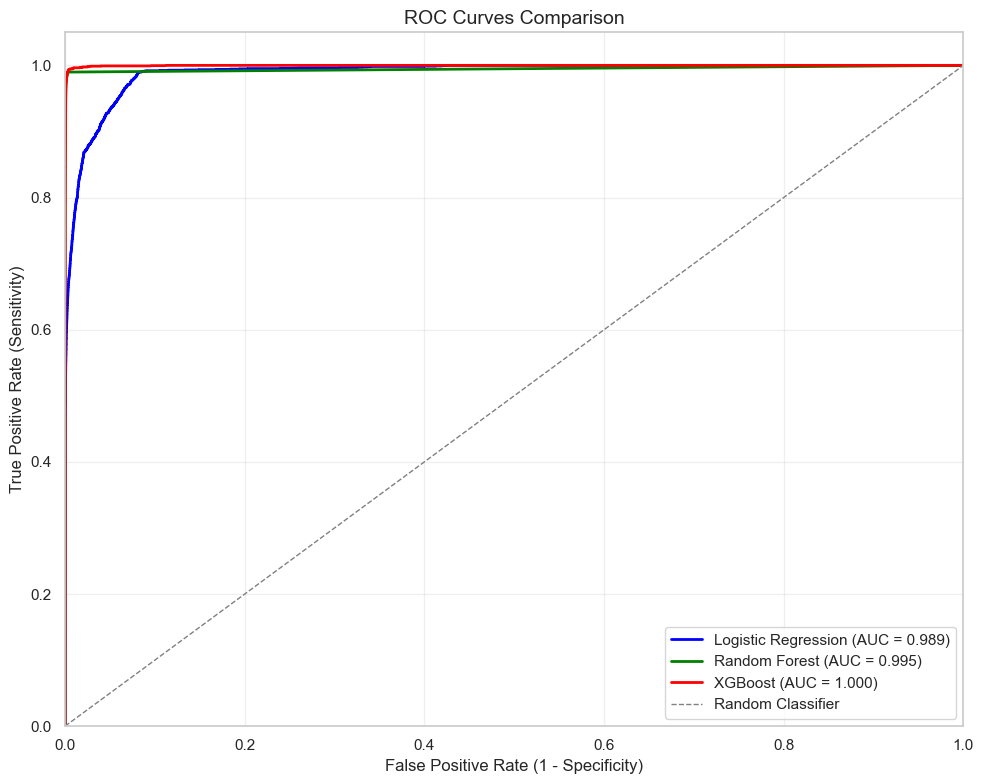

In [19]:
# Step 17: ROC Curves For All Models

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red']
models_roc = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

for idx, (name, model) in enumerate(models_roc.items()):
    # Get prediction probabilities
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot curve
    plt.plot(fpr, tpr, color=colors[idx], lw=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

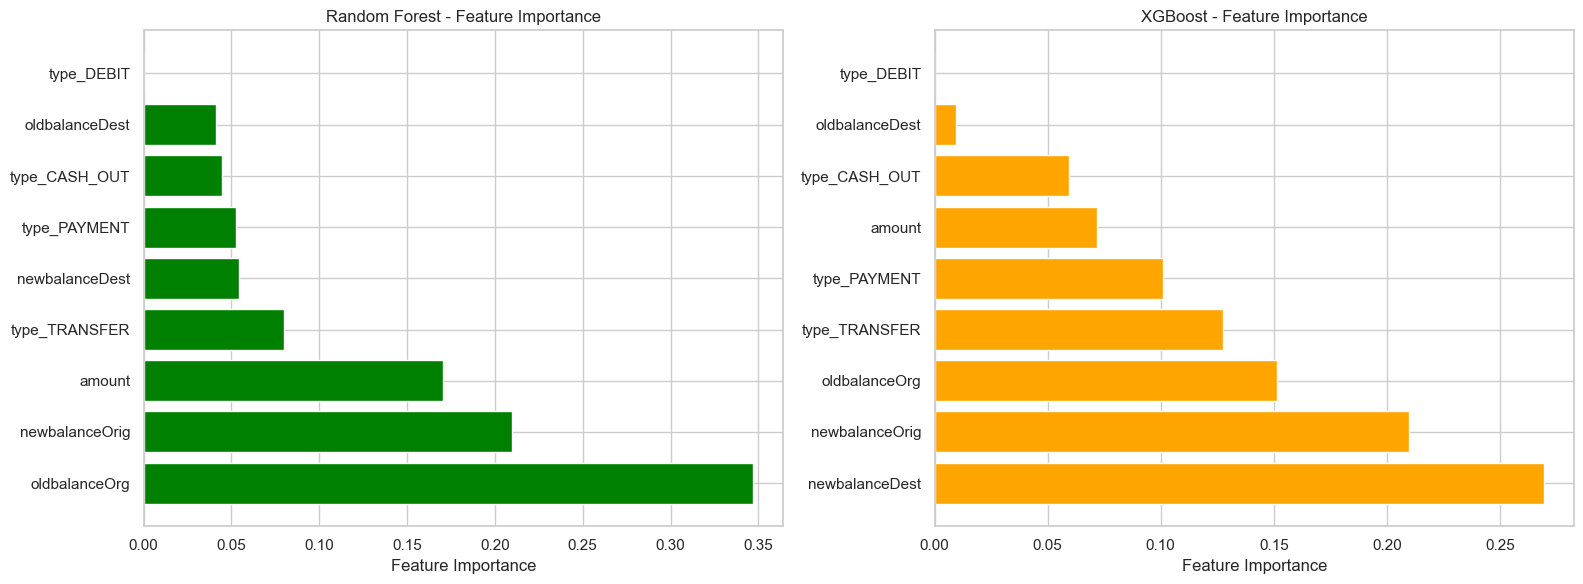


TOP 5 FEATURES - Random Forest
1. oldbalanceOrg: 0.3467
2. newbalanceOrig: 0.2097
3. amount: 0.1706
4. type_TRANSFER: 0.0802
5. newbalanceDest: 0.0545

TOP 5 FEATURES - XGBoost
1. newbalanceDest: 0.2693
2. newbalanceOrig: 0.2098
3. oldbalanceOrg: 0.1513
4. type_TRANSFER: 0.1275
5. type_PAYMENT: 0.1011


In [20]:
# Step 18: Feature Importance Analysis

# Get feature names after preprocessing
feature_names = numeric + list(preprocessor.named_transformers_['cat'].get_feature_names_out(['type']))

# 1. Random Forest Feature Importance
rf_model = pipeline_rf.named_steps['clf']
rf_importance = rf_model.feature_importances_

# 2. XGBoost Feature Importance
xgb_model = pipeline_xgb.named_steps['clf']
xgb_importance = xgb_model.feature_importances_

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_sorted_idx = np.argsort(rf_importance)[::-1]
axes[0].barh(range(len(rf_sorted_idx)), rf_importance[rf_sorted_idx], color='green')
axes[0].set_yticks(range(len(rf_sorted_idx)))
axes[0].set_yticklabels(np.array(feature_names)[rf_sorted_idx])
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Random Forest - Feature Importance', fontsize=12)

# XGBoost
xgb_sorted_idx = np.argsort(xgb_importance)[::-1]
axes[1].barh(range(len(xgb_sorted_idx)), xgb_importance[xgb_sorted_idx], color='orange')
axes[1].set_yticks(range(len(xgb_sorted_idx)))
axes[1].set_yticklabels(np.array(feature_names)[xgb_sorted_idx])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost - Feature Importance', fontsize=12)

plt.tight_layout()
plt.show()

# Print top 5 features for each model
print("\n" + "="*50)
print("TOP 5 FEATURES - Random Forest")
print("="*50)
for i in range(5):
    idx = rf_sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]}: {rf_importance[idx]:.4f}")

print("\n" + "="*50)
print("TOP 5 FEATURES - XGBoost")
print("="*50)
for i in range(5):
    idx = xgb_sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]}: {xgb_importance[idx]:.4f}")